In [66]:
import numpy as np;
from matplotlib import pyplot as plt
import scipy.integrate as integrate

# Exercise 08: Variational Monte Carlo and Simulated Annealing
## The Physical Problem
The goal of this exercise is to find the ground state energy and the corresponding probability density of a single quantum particle in a 1D double-well potential:
$$V(x) = x^4 - \frac{5}{2}x^2$$

Since this potential cannot be solved exactly analytically, we rely on the **Variational Principle**. This principle states that the expectation value of the Hamiltonian $\langle \hat{H} \rangle$ evaluated for any trial wave function $\Psi_T(x)$ is a rigorous upper bound to the true ground state energy $E_0$:
$$E_T = \frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}{\int dx |\Psi_T(x)|^2} \ge E_0$$

We propose a trial wave function modeled as the superposition of two Gaussians, introducing two variational parameters, $\mu$ (mean) and $\sigma$ (standard deviation):
$$\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

The objective is to compute the integral $E_T$ and find the optimal set of parameters $(\mu, \sigma)$ that minimizes it.

## Computational Architecture

Our solution is divided into two distinct computational phases, implemented in C++: the first is the **Optimization Phase** and the second is the **Production Phase**, which uses the results from the Optimization Phase.

These tasks require the calculation of the square modulus of the wavefunction and its second derivative for the calculation of the kinetic energy.

### 1. Calculation of $|\Psi_T|^2$ for Metropolis Sampling
The trial wave function is a symmetric superposition of two Gaussians:
$$\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

For the Metropolis algorithm, we need to sample the probability density $|\Psi_T|^2$. Since the Metropolis acceptance ratio only depends on the relative probabilities, we can drop all normalization factors that do not depend on the position $x$:

$$
\begin{aligned}
|\Psi_T^{\mu, \sigma}(x)|^2 &\propto \left( e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}} \right)^2 \\
&= e^{-\frac{(x-\mu)^2}{\sigma^2}} + e^{-\frac{(x+\mu)^2}{\sigma^2}} + 2e^{-\frac{x^2+\mu^2}{\sigma^2}} \\
&= e^{-\frac{x^2+\mu^2}{\sigma^2}}\left[e^{\frac{2x\mu}{\sigma^2}} + e^{-\frac{2x\mu}{\sigma^2}} + 2\right] \\
&\propto e^{-\frac{x^2}{\sigma^2}} \cosh^2\left(\frac{x\mu}{\sigma^2}\right)
\end{aligned}
$$

This compact form is computationally efficient and prevents numerical overflow/underflow during the simulation.

### 2. Analytical Calculation of the Local Energy
To compute the expectation value of the Hamiltonian $\langle \hat{H} \rangle_T$, we evaluate the local energy $E_{loc}(x)$ at each sampled configuration. Setting $\hbar = 1$ and $m = 1$, the kinetic part of the local energy is given by:
$$K_{loc}(x) = \frac{-\frac{1}{2}\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}$$

First, we compute the first derivative:
$$\frac{\partial}{\partial x} \Psi^{\mu, \sigma}_T(x) = -\frac{1}{\sigma^2}\left[(x-\mu)e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right]$$

Next, we evaluate the second derivative:
$$
\begin{aligned}
\frac{\partial^2}{\partial x^2} \Psi^{\mu, \sigma}_T(x) &= -\frac{1}{\sigma^2}\left[e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] + \frac{1}{\sigma^4}\left[(x-\mu)^2e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)^2e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] \\
&= -\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}\left[e^{-\frac{(x+\mu)^2}{2\sigma^2}} - e^{-\frac{(x-\mu)^2}{2\sigma^2}}\right] \\
&= -\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}e^{-\frac{x^2+\mu^2}{2\sigma^2}}\left[e^{-\frac{x\mu}{\sigma^2}} - e^{\frac{x\mu}{\sigma^2}}\right]
\end{aligned}
$$

Dividing by the wave function $\Psi_T(x) = e^{-\frac{x^2+\mu^2}{2\sigma^2}}\left[e^{\frac{x\mu}{\sigma^2}} + e^{-\frac{x\mu}{\sigma^2}}\right]$ yields the hyperbolic tangent:
$$\frac{\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = -\frac{1}{\sigma^2} + \frac{x^2 + \mu^2}{\sigma^4} - \frac{2x\mu}{\sigma^4} \tanh\left(\frac{x\mu}{\sigma^2}\right)$$

Finally, multiplying by $-\frac{1}{2}$, we obtain the analytical expression implemented in our C++ code:
$$K_{loc}(x) = \frac{1}{2\sigma^2} - \frac{x^2 + \mu^2}{2\sigma^4} + \frac{x\mu}{\sigma^4} \tanh\left(\frac{x\mu}{\sigma^2}\right)$$

### Phase 1: Optimization (Simulated Annealing)
To minimize the multidimensional integral $E_T$, we treat it as a cost function and explore the $(\mu, \sigma)$ parameter space using a **Simulated Annealing (SA)** algorithm. 
* We introduce a fictitious temperature $T$.
* At each step, we propose a random shift in $\mu$ and $\sigma$.
* The energy of the new configuration is evaluated using a short **Variational Monte Carlo (VMC)** run (Metropolis algorithm sampling $|\Psi_T(x)|^2$).
* Moves that lower the energy are always accepted. Uphill moves are accepted with a probability $p = e^{-\Delta E / T}$.
* The temperature is slowly decreased (geometric cooling), allowing the system to escape local minima at high temperatures and freeze into the global minimum at low temperatures.

The plots below visualize this search process, showing the energy converging as the temperature drops and the trajectory of the random walker in the parameter space.

In [85]:
SA_step, temperature, energy, energy_error = np.loadtxt("outputs/energy.dat", unpack=True)
SA_step, temperature, mu, sigma = np.loadtxt("outputs/mu_sigma.dat", unpack=True)

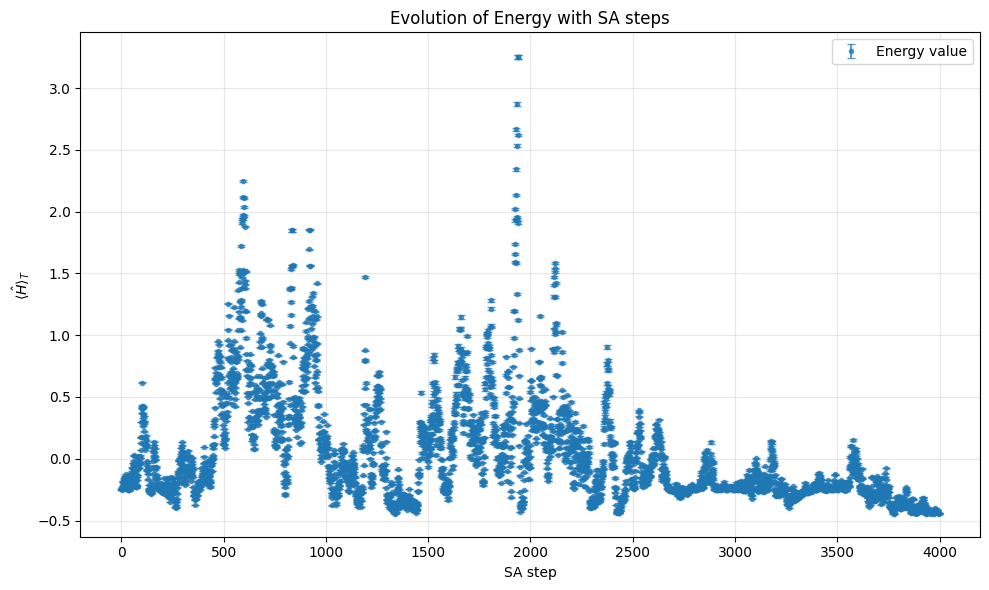

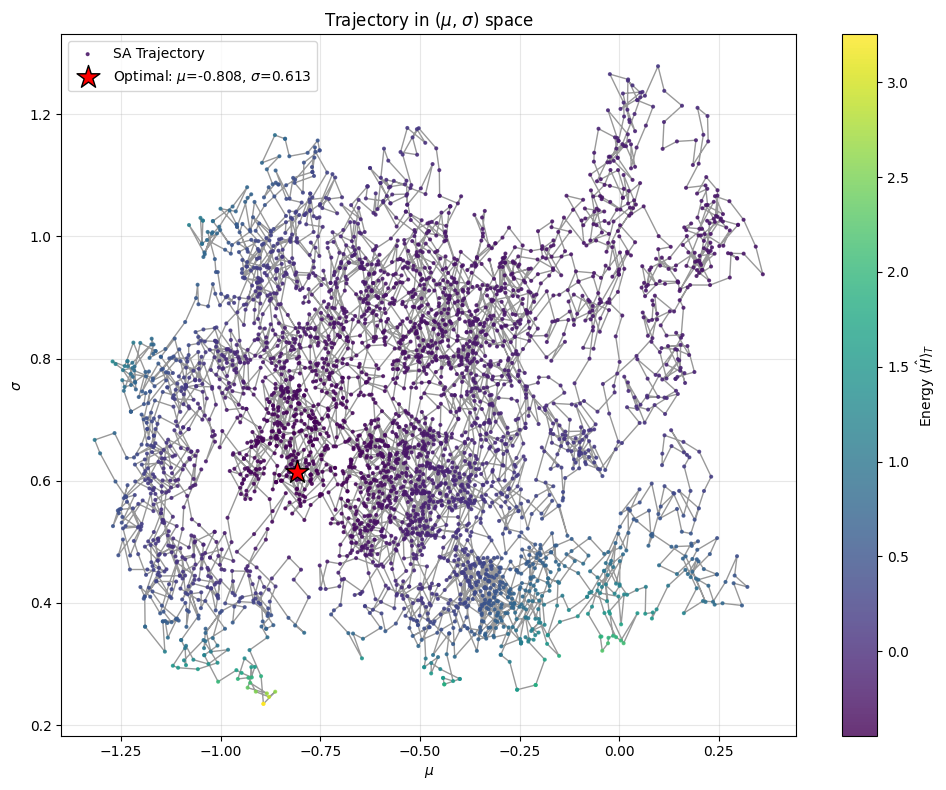

In [95]:
# =========================================================
# FIGURE 1: Energy Evolution
# =========================================================
plt.figure(figsize=(10, 6))

plt.errorbar(SA_step, energy, yerr=energy_error, fmt='.', label='Energy value', capsize=3, alpha=0.7)
plt.title('Evolution of Energy with SA steps')
plt.ylabel(r'$\langle {\hat H} \rangle_T$')
plt.xlabel('SA step')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# FIGURE 2: Trajectory in Parameter Space
# =========================================================
plt.figure(figsize=(10, 8))

plt.plot(mu, sigma, color='gray', alpha=0.8, linewidth=1.0, zorder=1)
sc = plt.scatter(mu, sigma, marker='.', c=energy, cmap='viridis', alpha=0.8, s=15, zorder=2, label='SA Trajectory')
cbar = plt.colorbar(sc)
cbar.set_label(r'Energy $\langle {\hat H} \rangle_T$')

# Optimal values
best_idx = np.argmin(energy)
best_mu = mu[best_idx]
best_sigma = sigma[best_idx]

plt.scatter(best_mu, best_sigma, marker='*', color='red', edgecolor='black', s=300, zorder=5, 
            label=f'Optimal: $\mu$={best_mu:.3f}, $\sigma$={best_sigma:.3f}')

plt.title("Trajectory in ($\mu$, $\sigma$) space")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Phase 2: The Production Run
During Simulated Annealing, the probability distribution is a "moving target" because $\mu$ and $\sigma$ are constantly changing. Therefore, the statistical uncertainties evaluated during the search are not definitive. 

Once the SA algorithm completes and identifies the absolute optimal parameters ($\mu_{best}$ and $\sigma_{best}$), we freeze the wave function. We then perform a final **Production Run**: a massive, high-statistics Variational Monte Carlo simulation. 

Using the **Data Blocking** method, we rigorously evaluate the final expectation value of the Hamiltonian $\langle {\hat H} \rangle_T$ and its statistical uncertainty.

In [81]:
blk, energy, error = np.loadtxt("outputs/best_energy_blocks.dat", unpack=True)

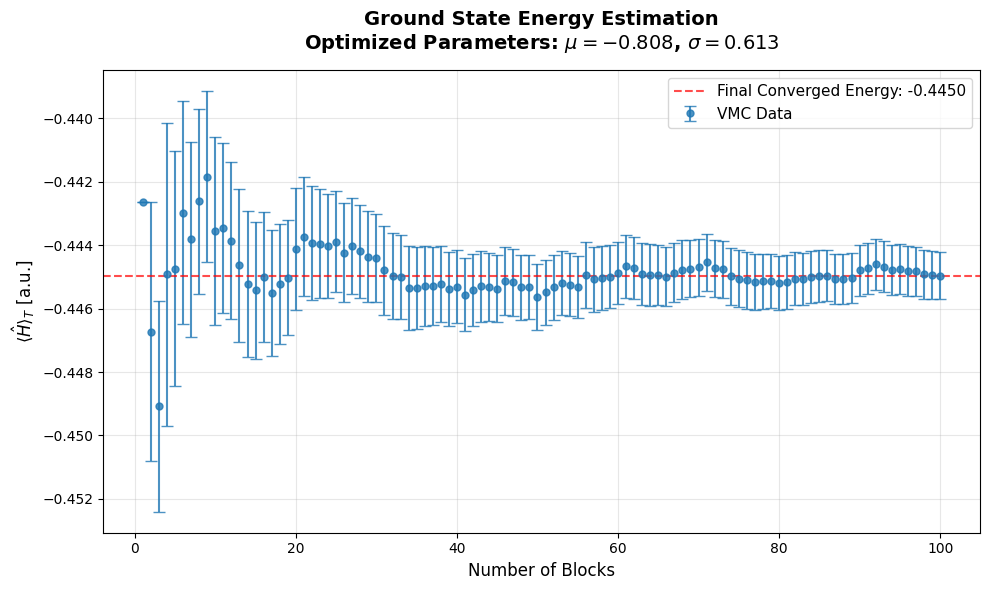

In [82]:
# =========================================================
# FIGURE 1: Energy vs. Block
# =========================================================
plt.figure(figsize=(10, 6))

plt.errorbar(x=blk, y=energy, yerr=error, fmt='o', elinewidth=1.5, capsize=4, markersize=5, 
             alpha=0.8, label=r'VMC Data')

# Horizontal line showing the final converged energy
final_energy = energy[-1]
plt.axhline(y=final_energy, color='red', linestyle='--', alpha=0.7, 
            label=f'Final Converged Energy: {final_energy:.4f}')

plt.xlabel("Number of Blocks", fontsize=12)
plt.ylabel(r"$\langle {\hat H} \rangle_T$ [a.u.]", fontsize=12)
plt.title(f"Ground State Energy Estimation\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ground State Probability Density
As a final validation of our computational pipeline, we extract the spatial configurations (the $x$ coordinates) visited by our Metropolis random walker during the production run. We use this to build a histogram representing the sampled probability density.

To prove the accuracy of our Variational Monte Carlo, we compare this histogram against two rigorous baselines:
1. **The Analytic Curve:** The mathematical formula of $|\Psi_T^{\mu, \sigma}(x)|^2$ evaluated with our optimal parameters.
2. **The True Ground State (Matrix Equation):** We transform the continuous time-independent Schrödinger equation into a discrete eigenvalue problem using the **Finite Differences** method. By diagonalizing the resulting Hamiltonian matrix, we obtain the exact numerical ground state energy and wave function.

The plot below superimposes our VMC sampling, our analytical approximation, and the true numerical ground state. The slight mismatch between our optimized trial wave function and the exact matrix solution visually demonstrates the fundamental limitation of the chosen functional form (the two Gaussians) and perfectly illustrates the Variational Principle in action.

In [75]:
# Potential energy
def Vpot(x):
    return (x**2 - 2.5)*x**2

# Analytical curve
def psi_T_sq(x_val, mu, sigma):
    term1 = np.exp(-(x_val - mu)**2 / (2 * sigma**2))
    term2 = np.exp(-(x_val + mu)**2 / (2 * sigma**2))
    return (term1 + term2)**2
norm, _ = integrate.quad(psi_T_sq, -10, 10, args=(best_mu, best_sigma))

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations for matrix form of Schroedinger equation

In [76]:
x_sampled = np.loadtxt("outputs/sampled_x.dat")
x_analytic = np.linspace(-a/2, a/2, N)
x_matrix = np.linspace(-a/2, a/2, N)

In [64]:
# Find analytical numerical solution to Schroedinger equation
dx = x_matrix[1] - x_matrix[0] # the step size
V = Vpot(x_matrix)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

psi_ground_sq = (psi[0])**2

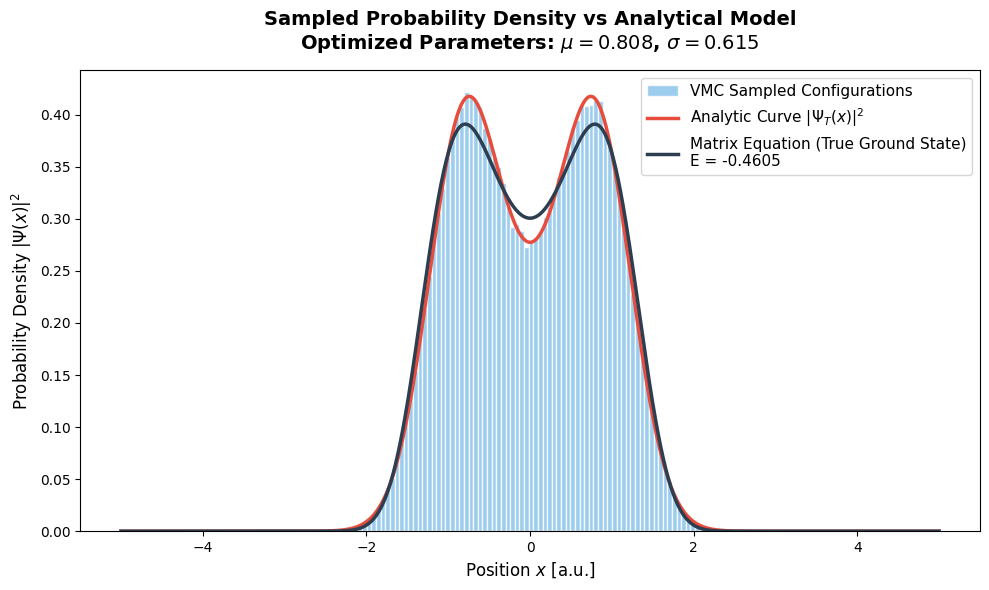

In [65]:
# ============================================================
# FIGURE 2: Sampled Wavefunction vs Analytical vs Numerical
# ============================================================
plt.figure(figsize=(10, 6))

# Simulation histogram
plt.hist(x=x_sampled, bins=100, density=True, color='#85C1E9', edgecolor='white', 
         alpha=0.8, label='VMC Sampled Configurations')

# Analytical curve
# Normalize first
y_analytic = psi_T_sq(x_analytic, best_mu, best_sigma) / norm
plt.plot(x_analytic, y_analytic, color='#E74C3C', linewidth=2.5, 
         label=r'Analytic Curve $|\Psi_T(x)|^2$')

# Matrix Numerical Solution
plt.plot(x_matrix, psi_ground_sq, color='#2C3E50', linewidth=2.5, 
         label=f'Matrix Equation (True Ground State)\nE = {E[0]:.4f}')



plt.xlabel("Position $x$ [a.u.]", fontsize=12)
plt.ylabel(r"Probability Density $|\Psi(x)|^2$", fontsize=12)
plt.title(f"Sampled Probability Density vs Analytical Model\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()